# Week 2 – Day 2: Feature Selection, Data Splitting & Supervised ML Setup

## 1) Introduction
Day 2 connects the prepared dataset from Day 1 to a supervised machine learning setup.

Today the focus is:
- target and features (`X` and `y`)
- train-test split
- avoiding data leakage
- feature selection methods
- simple model comparison

### Day 2 workflow
Prepared dataset -> `X` and `y` -> train/test split -> preprocessing -> feature selection -> simple model check

## 2) Import Libraries
We import the core tools used in Day 2 slides and practical coding.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

from sklearn.feature_selection import (
    SelectKBest,
    f_regression,
    mutual_info_regression,
    RFE,
    SequentialFeatureSelector
)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%matplotlib inline

### Why each import is useful (Day 2 workflow mapping)
- `pandas`, `numpy`: load/create data and handle numeric operations.
- `matplotlib.pyplot`: basic plots for feature scores and importance.
- `train_test_split`: creates training and testing sets correctly.
- `cross_val_score`, `KFold`: cross-validation for stable performance estimates.
- `SimpleImputer`: handles missing values.
- `OneHotEncoder`: converts categorical values to numeric vectors.
- `StandardScaler`: scales numeric columns to similar ranges.
- `ColumnTransformer`: applies different preprocessing to numeric vs categorical columns.
- `Pipeline`: combines preprocessing and model steps safely and reproducibly.
- `LinearRegression`: baseline regression model for comparison.
- `Ridge`, `Lasso`: embedded regularized methods for coefficient-based selection behavior.
- `RandomForestRegressor`: optional embedded method with feature importances.
- `SelectKBest`, `f_regression`, `mutual_info_regression`: filter-based feature selection.
- `RFE`, `SequentialFeatureSelector`: wrapper-based feature selection.
- `mean_absolute_error`, `mean_squared_error`, `r2_score`: quick baseline checks (detailed metrics are Day 3).

## 3) Load or Create Dataset
We try to load the Day 1 dataset from `data/week2/day1_house_energy_sample.csv`.
If it does not exist, we create a synthetic version (~150 rows), save it, and continue.

In [2]:
# Paths
dataset_path = '../../data/week2/day1_house_energy_sample.csv'
os.makedirs('../../data/week2', exist_ok=True)

if not os.path.exists(dataset_path):
    # Reproducible synthetic fallback dataset
    rng = np.random.default_rng(42)
    n = 150

    house_size_m2 = np.clip(rng.normal(135, 48, n), 40, 450)
    bedrooms = np.clip(np.round(house_size_m2 / 35 + rng.normal(0, 1.0, n)), 1, 8).astype(int)
    building_age_years = np.clip(rng.normal(30, 22, n), 1, 120)
    city = rng.choice(['Berlin', 'Munich', 'Hamburg', 'Cologne', 'Leipzig'], n, p=[0.25, 0.2, 0.2, 0.2, 0.15])
    heating_type = rng.choice(['Gas', 'Electric', 'Heat Pump', 'District'], n, p=[0.38, 0.25, 0.22, 0.15])
    insulation_grade = rng.choice(['A', 'B', 'C', 'D'], n, p=[0.18, 0.35, 0.3, 0.17])
    average_temperature_c = np.clip(rng.normal(10.5, 5, n), -7, 24)

    insulation_effect = pd.Series(insulation_grade).map({'A': -1300, 'B': -650, 'C': 180, 'D': 1050}).to_numpy()
    heating_effect = pd.Series(heating_type).map({'Heat Pump': -850, 'District': -300, 'Gas': 220, 'Electric': 520}).to_numpy()
    city_effect = pd.Series(city).map({'Berlin': 120, 'Munich': 260, 'Hamburg': 150, 'Cologne': 90, 'Leipzig': -40}).to_numpy()
    noise = rng.normal(0, 420, n)

    energy_consumption_kwh = (
        3600
        + 23 * house_size_m2
        + 15 * building_age_years
        + (14 - average_temperature_c) * 175
        + insulation_effect
        + heating_effect
        + city_effect
        + noise
    )
    energy_consumption_kwh = np.clip(energy_consumption_kwh, 1500, None)

    df_synth = pd.DataFrame({
        'house_size_m2': house_size_m2.round(1),
        'bedrooms': bedrooms,
        'building_age_years': building_age_years.round(1),
        'city': city,
        'heating_type': heating_type,
        'insulation_grade': insulation_grade,
        'average_temperature_c': average_temperature_c.round(1),
        'energy_consumption_kwh': energy_consumption_kwh.round(1),
    })

    # Add some missing values
    for col in ['house_size_m2', 'building_age_years', 'average_temperature_c']:
        idx = rng.choice(df_synth.index, size=5, replace=False)
        df_synth.loc[idx, col] = np.nan

    for col in ['city', 'heating_type', 'insulation_grade']:
        idx = rng.choice(df_synth.index, size=4, replace=False)
        df_synth.loc[idx, col] = np.nan

    # Add outliers
    df_synth.loc[3, ['house_size_m2', 'energy_consumption_kwh']] = [520, 34000]
    df_synth.loc[55, ['building_age_years', 'energy_consumption_kwh']] = [140, 28000]
    df_synth.loc[103, ['average_temperature_c', 'energy_consumption_kwh']] = [-18, 30000]

    df_synth.to_csv(dataset_path, index=False)
    print('Dataset not found. Created synthetic dataset at:', dataset_path)

df = pd.read_csv(dataset_path)
print('Loaded dataset from:', dataset_path)

Loaded dataset from: data/week2/day1_house_energy_sample.csv


Quick inspection tools:
- `df.head()`: first rows preview
- `df.shape`: size as `(rows, columns)`
- `df.info()`: non-null counts and data types
- `df.describe()`: numeric summary statistics

In [3]:
display(df.head())
print('Shape:', df.shape)
print('\nInfo:')
df.info()
print('\nDescribe:')
display(df.describe())

,house_size_m2,bedrooms,building_age_years,city,heating_type,insulation_grade,average_temperature_c,energy_consumption_kwh
0,149.6,4,68.0,Hamburg,Gas,C,8.3,9367.1
1,85.1,1,1.0,Munich,Heat Pump,B,-2.0,7471.7
2,171.0,3,49.0,Hamburg,Electric,C,2.0,11506.6
3,520.0,5,22.8,Berlin,District,C,6.3,34000.0
4,41.4,1,28.7,Berlin,Electric,D,NaN,8180.4


Shape: (150, 8)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   house_size_m2           145 non-null    float64
 1   bedrooms                150 non-null    int64  
 2   building_age_years      145 non-null    float64
 3   city                    146 non-null    object 
 4   heating_type            146 non-null    object 
 5   insulation_grade        146 non-null    object 
 6   average_temperature_c   145 non-null    float64
 7   energy_consumption_kwh  150 non-null    float64
dtypes: float64(4), int64(1), object(3)
memory usage: 9.5+ KB

Describe:


,house_size_m2,bedrooms,building_age_years,average_temperature_c,energy_consumption_kwh
count,145.000000,150.000000,145.000000,145.000000,150.000000
mean,135.731034,3.786667,32.541379,10.260000,8121.080000
std,52.046221,1.599441,21.948762,5.432188,3630.489948
min,40.000000,1.000000,1.000000,-18.000000,3726.700000
25%,104.300000,3.000000,15.200000,8.000000,6392.475000
50%,135.600000,4.000000,33.000000,10.800000,7533.100000
75%,161.100000,5.000000,47.700000,13.300000,8704.975000
max,520.000000,8.000000,140.000000,21.700000,34000.000000


## 4) Define Supervised Learning Task
This is a **supervised regression** task: the target is known and continuous.

In [4]:
target = 'energy_consumption_kwh'
X = df.drop(columns=[target])
y = df[target]

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (150, 7)
y shape: (150,)


- `X`: input features used for prediction
- `y`: target we want to predict
- separating them keeps the workflow clear and prevents mistakes

| Column | Role | Type | Reason |
|---|---|---|---|
| house_size_m2 | Feature | Numerical | Larger houses usually need more energy |
| bedrooms | Feature | Numerical | Extra signal about dwelling size/use |
| building_age_years | Feature | Numerical | Older buildings may be less efficient |
| city | Feature | Categorical | Regional differences can affect use |
| heating_type | Feature | Categorical | Heating system influences consumption |
| insulation_grade | Feature | Categorical | Better insulation lowers demand |
| average_temperature_c | Feature | Numerical | Colder temperature often increases heating demand |
| energy_consumption_kwh | Target | Numerical | Value to predict |

## 5) Identify Numerical and Categorical Features
Different feature types need different preprocessing steps.

In [5]:
numerical_features = [
    'house_size_m2',
    'bedrooms',
    'building_age_years',
    'average_temperature_c'
]

categorical_features = [
    'city',
    'heating_type',
    'insulation_grade'
]

print('Numerical features:', numerical_features)
print('Categorical features:', categorical_features)

Numerical features: ['house_size_m2', 'bedrooms', 'building_age_years', 'average_temperature_c']
Categorical features: ['city', 'heating_type', 'insulation_grade']


- Numerical features: usually imputed and scaled.
- Categorical features: must be encoded to numeric format.
- Splitting by type helps build clean, safe preprocessing pipelines.

## 6) Train-Test Split
We split before fitting preprocessing or feature selection.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train shape: (120, 7)
X_test shape: (30, 7)
y_train shape: (120,)
y_test shape: (30,)


- training data learns patterns
- test data stays untouched for final checking
- `test_size=0.2` means 20% test set
- `random_state=42` ensures reproducible split

## 7) Important: Avoid Data Leakage
Data leakage happens when test-set information is used during training.

Common leakage examples:
- scaling the full dataset before splitting
- imputing missing values using full data
- selecting features on all data before split
- creating features directly from the target

**Teaching point:** all preprocessing and feature selection must be fitted on training data only, then applied to test data.

## 8) Build Preprocessing Pipeline
We define separate pipelines for numeric and categorical columns and combine them with `ColumnTransformer`.

In [7]:
# Numerical pipeline: fill missing values, then scale
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: fill missing categories, then one-hot encode
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

print('Preprocessor created successfully.')

Preprocessor created successfully.


- `SimpleImputer`: fills missing values.
- `StandardScaler`: standardizes numerical columns.
- `OneHotEncoder`: converts categories to model-friendly numeric columns.
- `ColumnTransformer`: applies the right transformation to each feature group.
- `Pipeline`: combines steps in a safe order.

## 9) Baseline Model (Reference Only)
This baseline gives us a simple reference before comparing feature-selection approaches.

In [8]:
baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)

baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_rmse = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
baseline_r2 = r2_score(y_test, y_pred_baseline)

print(f'Baseline MAE:  {baseline_mae:.2f}')
print(f'Baseline RMSE: {baseline_rmse:.2f}')
print(f'Baseline R^2:  {baseline_r2:.3f}')

Baseline MAE:  1271.48
Baseline RMSE: 3518.38
Baseline R^2:  0.217


## 10) Filter Method 1: Correlation (Numerical Features)
Pearson correlation measures linear relation with the target for numerical features.

,correlation_with_target,abs_correlation
house_size_m2,0.549346,0.549346
average_temperature_c,-0.448978,0.448978
building_age_years,0.230178,0.230178
bedrooms,0.219680,0.219680


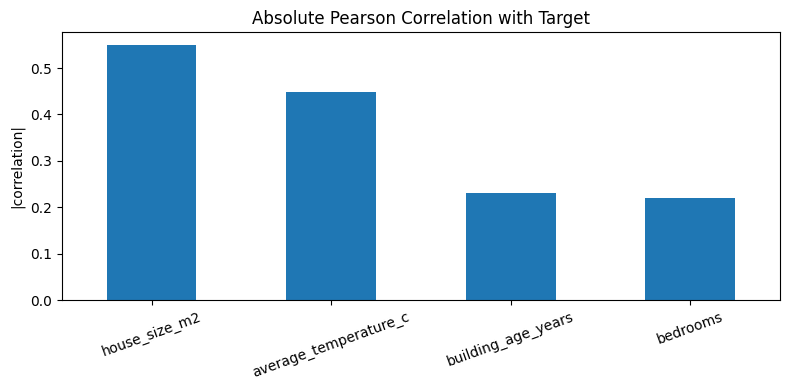

Top numerical features by absolute correlation: ['house_size_m2', 'average_temperature_c', 'building_age_years']


In [9]:
corr_df = df[numerical_features + [target]].copy()
corr_df = corr_df.fillna(corr_df.median(numeric_only=True))

corr_series = corr_df.corr()[target].drop(target)
corr_abs = corr_series.abs().sort_values(ascending=False)

display(pd.DataFrame({'correlation_with_target': corr_series, 'abs_correlation': corr_series.abs()}).sort_values('abs_correlation', ascending=False))

plt.figure(figsize=(8, 4))
corr_abs.plot(kind='bar')
plt.title('Absolute Pearson Correlation with Target')
plt.ylabel('|correlation|')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

top_corr_features = corr_abs.head(3).index.tolist()
print('Top numerical features by absolute correlation:', top_corr_features)

Interpretation:
- near `+1` or `-1`: strong linear relation
- near `0`: weak linear relation
- correlation is useful, but it does not capture every non-linear pattern

## 11) Filter Method 2: SelectKBest with `f_regression`
`SelectKBest` keeps the top `k` features by score. For this regression target, we use `f_regression`.

**Note:** In the slides, ANOVA F-test is introduced for classification. For regression tasks, `f_regression` is a related filter method for numerical targets.

In [10]:
def get_feature_names_from_preprocessor(fitted_preprocessor):
    names = []
    for name, transformer, cols in fitted_preprocessor.transformers_:
        if name == 'remainder':
            continue

        if hasattr(transformer, 'named_steps'):
            last_step = list(transformer.named_steps.values())[-1]
            if hasattr(last_step, 'get_feature_names_out'):
                if isinstance(cols, list):
                    out_names = last_step.get_feature_names_out(cols)
                else:
                    out_names = last_step.get_feature_names_out()
                names.extend(out_names)
            else:
                names.extend(cols)
        else:
            if hasattr(transformer, 'get_feature_names_out'):
                names.extend(transformer.get_feature_names_out(cols))
            else:
                names.extend(cols)
    return list(names)

# Fit preprocessor only on training data
X_train_processed = preprocessor.fit_transform(X_train)
feature_names = get_feature_names_from_preprocessor(preprocessor)

selector_f = SelectKBest(score_func=f_regression, k=3)
selector_f.fit(X_train_processed, y_train)

f_scores_df = pd.DataFrame({
    'feature': feature_names,
    'f_score': selector_f.scores_
}).sort_values('f_score', ascending=False)

selected_f_features = f_scores_df.head(3)['feature'].tolist()
display(f_scores_df.head(15))
print('SelectKBest (f_regression) selected features:', selected_f_features)

,feature,f_score
0,house_size_m2,91.057179
3,average_temperature_c,50.536597
1,bedrooms,8.085150
13,insulation_grade_A,6.420929
16,insulation_grade_D,4.909076
4,city_Berlin,2.773585
15,insulation_grade_C,2.247782
7,city_Leipzig,2.240496
12,heating_type_Heat Pump,1.949006
14,insulation_grade_B,1.642036


SelectKBest (f_regression) selected features: ['house_size_m2', 'average_temperature_c', 'bedrooms']


- `SelectKBest`: keeps top features by statistical score.
- `f_regression`: tests linear relation strength for regression targets.
- `k=3`: we keep only three strongest scored features.

## 12) Filter Method 3: Mutual Information
Mutual information can capture non-linear dependency better than plain correlation in some cases.

,feature,mi_score
3,average_temperature_c,0.117226
0,house_size_m2,0.090752
13,insulation_grade_A,0.089602
14,insulation_grade_B,0.080670
1,bedrooms,0.072195
6,city_Hamburg,0.052823
15,insulation_grade_C,0.035011
8,city_Munich,0.030766
16,insulation_grade_D,0.019764
5,city_Cologne,0.011776


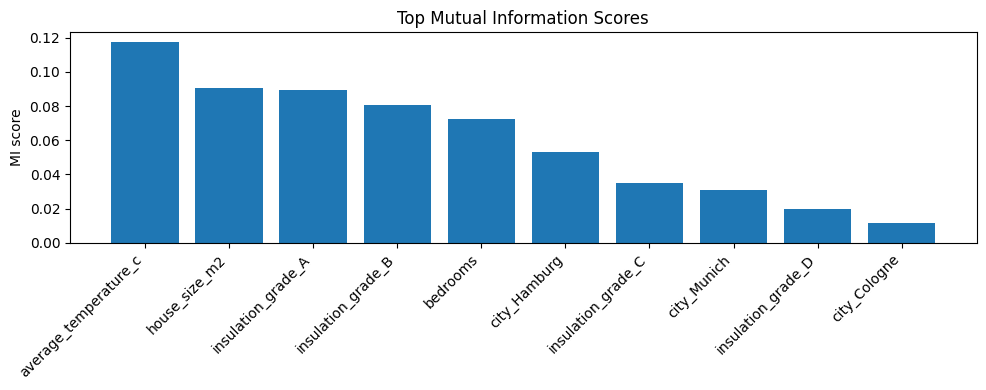

Mutual information selected (top 3): ['average_temperature_c', 'house_size_m2', 'insulation_grade_A']


In [11]:
mi_scores = mutual_info_regression(X_train_processed, y_train, random_state=42)
mi_df = pd.DataFrame({'feature': feature_names, 'mi_score': mi_scores}).sort_values('mi_score', ascending=False)

display(mi_df.head(15))

plt.figure(figsize=(10, 4))
top_mi = mi_df.head(10)
plt.bar(top_mi['feature'], top_mi['mi_score'])
plt.title('Top Mutual Information Scores')
plt.ylabel('MI score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

selected_mi_features = mi_df.head(3)['feature'].tolist()
print('Mutual information selected (top 3):', selected_mi_features)

- score `0` means no useful dependency detected.
- higher scores mean stronger information about the target.
- MI can detect some non-linear relationships.

## 13) Wrapper Method 1: Recursive Feature Elimination (RFE)
RFE starts with all features, trains a model, removes weaker ones, and repeats.

In [12]:
rfe = RFE(estimator=LinearRegression(), n_features_to_select=3)
rfe.fit(X_train_processed, y_train)

rfe_selected = [name for name, keep in zip(feature_names, rfe.support_) if keep]
rfe_ranking_df = pd.DataFrame({'feature': feature_names, 'rfe_rank': rfe.ranking_}).sort_values('rfe_rank')

display(rfe_ranking_df.head(15))
print('RFE selected features:', rfe_selected)

,feature,rfe_rank
0,house_size_m2,1
3,average_temperature_c,1
16,insulation_grade_D,1
13,insulation_grade_A,2
14,insulation_grade_B,3
12,heating_type_Heat Pump,4
1,bedrooms,5
10,heating_type_Electric,6
8,city_Munich,7
11,heating_type_Gas,8


RFE selected features: ['house_size_m2', 'average_temperature_c', 'insulation_grade_D']


## 14) Wrapper Method 2: Forward Feature Selection
Forward selection starts with no features, then adds the most useful one step by step using cross-validation.

In [13]:
forward_sfs = SequentialFeatureSelector(
    LinearRegression(),
    n_features_to_select=3,
    direction='forward',
    scoring='neg_mean_squared_error',
    cv=5
)

forward_sfs.fit(X_train_processed, y_train)
forward_selected = [name for name, keep in zip(feature_names, forward_sfs.get_support()) if keep]

print('Forward selection features:', forward_selected)

Forward selection features:

 ['house_size_m2', 'average_temperature_c', 'insulation_grade_D']


## 15) Embedded Method 1: Lasso Regression
Lasso performs feature selection during training by shrinking some coefficients to zero.

In [14]:
lasso = Lasso(alpha=0.1, max_iter=10000)
lasso.fit(X_train_processed, y_train)

lasso_coef_df = pd.DataFrame({
    'feature': feature_names,
    'lasso_coefficient': lasso.coef_
}).sort_values('lasso_coefficient', key=np.abs, ascending=False)

display(lasso_coef_df.head(15))

lasso_near_zero = lasso_coef_df[np.abs(lasso_coef_df['lasso_coefficient']) < 1e-3]['feature'].tolist()
selected_lasso_features = lasso_coef_df[np.abs(lasso_coef_df['lasso_coefficient']) >= 1e-3]['feature'].tolist()

print('Lasso near-zero coefficient features:', lasso_near_zero[:10])
print('Lasso non-zero selected feature count:', len(selected_lasso_features))

,feature,lasso_coefficient
0,house_size_m2,2635.364612
13,insulation_grade_A,-1749.008894
16,insulation_grade_D,1610.668980
3,average_temperature_c,-1583.663004
14,insulation_grade_B,-1135.458133
12,heating_type_Heat Pump,-892.439538
10,heating_type_Electric,811.425311
1,bedrooms,-758.704510
8,city_Munich,-393.040229
11,heating_type_Gas,348.175625


Lasso near-zero coefficient features: ['city_Hamburg', 'insulation_grade_C']
Lasso non-zero selected feature count: 15


- Lasso is an embedded method.
- `alpha` controls regularization strength.
- stronger regularization can force more coefficients to zero.

## 16) Embedded Method 2: Ridge Regression
Ridge shrinks coefficients toward zero but usually keeps them non-zero.

In [15]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_processed, y_train)

ridge_coef_df = pd.DataFrame({
    'feature': feature_names,
    'ridge_coefficient': ridge.coef_
}).sort_values('ridge_coefficient', key=np.abs, ascending=False)

coef_compare_df = lasso_coef_df.merge(ridge_coef_df, on='feature', how='inner')
display(coef_compare_df.head(15))

,feature,lasso_coefficient,ridge_coefficient
0,house_size_m2,2635.364612,2591.023737
1,insulation_grade_A,-1749.008894,-1365.271486
2,insulation_grade_D,1610.668980,1844.855283
3,average_temperature_c,-1583.663004,-1575.088998
4,insulation_grade_B,-1135.458133,-794.103915
5,heating_type_Heat Pump,-892.439538,-909.991961
6,heating_type_Electric,811.425311,706.295354
7,bedrooms,-758.704510,-728.021763
8,city_Munich,-393.040229,-324.956329
9,heating_type_Gas,348.175625,275.979089


Ridge is useful when features are correlated because it stabilizes coefficient values instead of hard-removing many features.

## 17) Optional Embedded Method 3: Random Forest Feature Importance
Tree-based models can provide feature importance scores and capture non-linear patterns.

,feature,importance
0,house_size_m2,0.464402
3,average_temperature_c,0.438023
2,building_age_years,0.019497
13,insulation_grade_A,0.017229
16,insulation_grade_D,0.014808
1,bedrooms,0.013605
12,heating_type_Heat Pump,0.005741
14,insulation_grade_B,0.004777
10,heating_type_Electric,0.003533
15,insulation_grade_C,0.003452


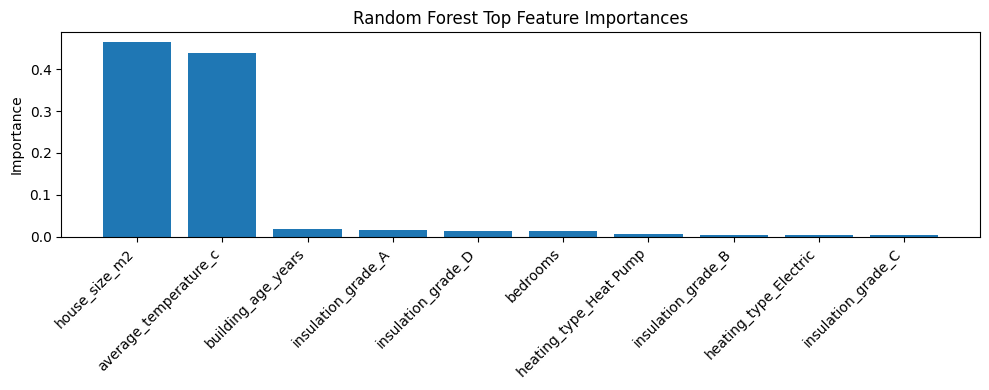

Random forest top 3 features: ['house_size_m2', 'average_temperature_c', 'building_age_years']


In [16]:
rf = RandomForestRegressor(random_state=42, n_estimators=200)
rf.fit(X_train_processed, y_train)

rf_imp_df = pd.DataFrame({
    'feature': feature_names,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

display(rf_imp_df.head(15))

plt.figure(figsize=(10, 4))
top_rf = rf_imp_df.head(10)
plt.bar(top_rf['feature'], top_rf['importance'])
plt.title('Random Forest Top Feature Importances')
plt.ylabel('Importance')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

selected_rf_features = rf_imp_df.head(3)['feature'].tolist()
print('Random forest top 3 features:', selected_rf_features)

## 18) Simple Comparison of Feature-Selection Approaches

In [17]:
comparison_table = pd.DataFrame([
    ['Correlation', 'Linear relation with target', 'Ranked correlations', 'Quick baseline for numeric features'],
    ['Mutual Information', 'Information dependency (can be non-linear)', 'MI scores', 'When non-linear relations may exist'],
    ['RFE', 'Remove weak features iteratively', 'Selected subset + ranking', 'When using a specific estimator'],
    ['Forward Selection', 'Add best feature step by step', 'Selected subset', 'When searching small useful subsets'],
    ['Lasso', 'Regularization with possible zero coefficients', 'Coefficient-based selection', 'When sparse solutions are preferred'],
    ['Ridge', 'Regularization shrinkage (usually non-zero)', 'Stabilized coefficients', 'When features are correlated'],
    ['Random Forest Importance', 'Tree-based importance during training', 'Importance scores', 'For non-linear interactions']
], columns=['Method', 'Idea', 'Output', 'Useful When'])

display(comparison_table)

,Method,Idea,Output,Useful When
0,Correlation,Linear relation with target,Ranked correlations,Quick baseline for numeric features
1,Mutual Information,Information dependency (can be non-linear),MI scores,When non-linear relations may exist
2,RFE,Remove weak features iteratively,Selected subset + ranking,When using a specific estimator
3,Forward Selection,Add best feature step by step,Selected subset,When searching small useful subsets
4,Lasso,Regularization with possible zero coefficients,Coefficient-based selection,When sparse solutions are preferred
5,Ridge,Regularization shrinkage (usually non-zero),Stabilized coefficients,When features are correlated
6,Random Forest Importance,Tree-based importance during training,Importance scores,For non-linear interactions


## 19) Cross-Validation Introduction
K-fold cross-validation gives a more stable estimate than one split by rotating validation folds.

In [18]:
cv_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_neg_mse = cross_val_score(
    cv_model,
    X_train,
    y_train,
    cv=kfold,
    scoring='neg_mean_squared_error'
)

cv_rmse_scores = np.sqrt(-cv_scores_neg_mse)
cv_rmse_mean = cv_rmse_scores.mean()
cv_rmse_std = cv_rmse_scores.std()

print('RMSE per fold:', np.round(cv_rmse_scores, 2))
print(f'Average RMSE: {cv_rmse_mean:.2f}')
print(f'RMSE std dev: {cv_rmse_std:.2f}')

RMSE per fold: [4926.99 1716.9  1342.36 1449.89 1017.85]
Average RMSE: 2090.80
RMSE std dev: 1435.68


- training data is split into `k` folds
- each fold becomes validation once
- performance is averaged for a more reliable estimate

## 20) Final Day 2 Summary
Today we learned:
- how to define `X` and `y`
- why train-test split is necessary
- how leakage can happen
- how filter methods select features before modeling
- how wrapper methods test feature subsets
- how embedded methods select features during model training
- how cross-validation gives a more reliable performance estimate

## 21) In-Class Task

**TODO 1:** Choose one feature-selection method from today.

**TODO 2:** Select the best 3-5 features.

**TODO 3:** Train a simple Linear Regression model using only selected features.

**TODO 4:** Compare it with the baseline model.

**TODO 5:** Write 3-5 sentences:
- Which features were selected?
- Did the selected-feature model improve?
- Which method was easiest to understand?
- Which method seems most useful and why?

## 22) Final Output
We print a compact Day 2 completion summary.

In [19]:
selected_features_summary = {
    'Correlation_top3': top_corr_features,
    'SelectKBest_f_regression_top3': selected_f_features,
    'MutualInformation_top3': selected_mi_features,
    'RFE_top3': rfe_selected,
    'ForwardSelection_top3': forward_selected,
    'RandomForest_top3': selected_rf_features
}

print('Week 2 Day 2 feature selection and splitting practical completed successfully.')
print('Train size:', X_train.shape, '| Test size:', X_test.shape)
print(f'Baseline metrics -> MAE: {baseline_mae:.2f}, RMSE: {baseline_rmse:.2f}, R^2: {baseline_r2:.3f}')
print('\nSelected features from each method:')
for method_name, features in selected_features_summary.items():
    print(f'- {method_name}: {features}')

print('\nCross-validation RMSE summary:')
print('Fold RMSE:', np.round(cv_rmse_scores, 2))
print(f'Average RMSE: {cv_rmse_mean:.2f}')
print(f'Standard deviation: {cv_rmse_std:.2f}')

Week 2 Day 2 feature selection and splitting practical completed successfully.
Train size: (120, 7) | Test size: (30, 7)
Baseline metrics -> MAE: 1271.48, RMSE: 3518.38, R^2: 0.217

Selected features from each method:
- Correlation_top3: ['house_size_m2', 'average_temperature_c', 'building_age_years']
- SelectKBest_f_regression_top3: ['house_size_m2', 'average_temperature_c', 'bedrooms']
- MutualInformation_top3: ['average_temperature_c', 'house_size_m2', 'insulation_grade_A']
- RFE_top3: ['house_size_m2', 'average_temperature_c', 'insulation_grade_D']
- ForwardSelection_top3: ['house_size_m2', 'average_temperature_c', 'insulation_grade_D']
- RandomForest_top3: ['house_size_m2', 'average_temperature_c', 'building_age_years']

Cross-validation RMSE summary:
Fold RMSE: [4926.99 1716.9  1342.36 1449.89 1017.85]
Average RMSE: 2090.80
Standard deviation: 1435.68
